# Module 5 — 矩陣分解與工程分析

> **對應程度**：大學線代核心，工程數值方法基礎

## 為什麼要「分解」矩陣？

就像把一個複雜的數字分解成質因數（例如 $60 = 2 \times 2 \times 3 \times 5$）可以幫助我們做除法一樣，**矩陣分解**是把一個複雜的矩陣拆成幾個結構簡單的矩陣相乘。

為什麼要這樣做？
- **更快求解方程組**：分解一次之後，可以快速解多組方程式
- **數值更穩定**：避免浮點數誤差累積
- **揭示矩陣的內在結構**：例如 SVD 能告訴我們資料的「重要方向」

| 分解方法 | 形式 | 適用條件 | 核心應用 |
|----------|------|----------|----------|
| LU | $A = LU$ | 方陣 | 反覆求解同一矩陣的不同方程 |
| QR | $A = QR$ | 任意矩陣 | 最小平方、正交化 |
| Cholesky | $A = LL^T$ | 對稱正定 | 熱傳導、結構分析（速度最快） |
| SVD | $A = U\Sigma V^T$ | 任意矩陣 | 壓縮、降維、秩分析（最通用） |

### 本模組涵蓋
1. LU 分解 — 高斯消去法的矩陣版本
2. QR 分解 — 正交化的力量
3. Cholesky 分解 — 對稱正定矩陣的加速器
4. SVD — 奇異值分解（核心中的核心）

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg as sla
import time
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.linalg_utils import (
    lu_decomposition, qr_decomposition, cholesky_decomposition
)
from src.physics_models import heat_conduction_1d
from src.visualizer import set_style, plot_matrix_heatmap

set_style()
print('Module 5 載入完成！')

Module 5 載入完成！


---
## 5.1 LU 分解

### 原理

LU 分解把矩陣 $A$ 拆成一個**下三角矩陣** $L$（Lower）和一個**上三角矩陣** $U$（Upper）的乘積：

$$A = LU$$

這其實就是**高斯消去法的矩陣版本**——$U$ 是消去後的上三角矩陣，$L$ 記錄了每一步消去時用的倍數。

### 直覺理解

想像你每天早上要幫全班 30 個同學算成績，計算方法相同（同一個矩陣 $A$），但每天的原始分數不同（不同的 $\vec{b}$）。

- **笨方法**：每天重新做一遍高斯消去法 → 每天花 $O(n^3)$ 的時間
- **聰明方法**：第一天做一次 LU 分解（$O(n^3)$），之後每天只需要做前向代換 + 回代（$O(n^2)$）

當你需要**用同一個矩陣解很多次方程**時，LU 分解可以省下大量計算。

### 實際例子：橋梁多工況分析

一座橋梁的剛度矩陣 $K$ 是固定的（結構不變），但荷載 $\vec{f}$ 會隨著不同情況改變：
- 工況 1：一輛卡車停在橋中央
- 工況 2：兩輛車分別在兩端
- 工況 3：整座橋承受均佈風力

工程師只需要對 $K$ 做一次 LU 分解，就能快速算出每種工況下的變形 $\vec{u}$。在大型有限元素模型中（$K$ 可能有百萬階），這個節省是巨大的。

In [2]:
# LU 分解基礎
A = np.array([[2, -1, 0], [-1, 2, -1], [0, -1, 2]], dtype=float)
L, U = lu_decomposition(A)

print('A =')
print(A)
print('\nL =')
print(np.round(L, 4))
print('\nU =')
print(np.round(U, 4))
print(f'\n重組誤差: {np.linalg.norm(L @ U - A):.2e} ✓')

A =
[[ 2. -1.  0.]
 [-1.  2. -1.]
 [ 0. -1.  2.]]

L =
[[ 1.      0.      0.    ]
 [-0.5     1.      0.    ]
 [ 0.     -0.6667  1.    ]]

U =
[[ 2.     -1.      0.    ]
 [ 0.      1.5    -1.    ]
 [ 0.      0.      1.3333]]

重組誤差: 0.00e+00 ✓


集中力（中間）: 最大位移 = 15.0000
均佈力: 最大位移 = 9.0000
三角形荷載: 最大位移 = 9.5000


/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 31227 (\N{CJK UNIFIED IDEOGRAPH-79FB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarni

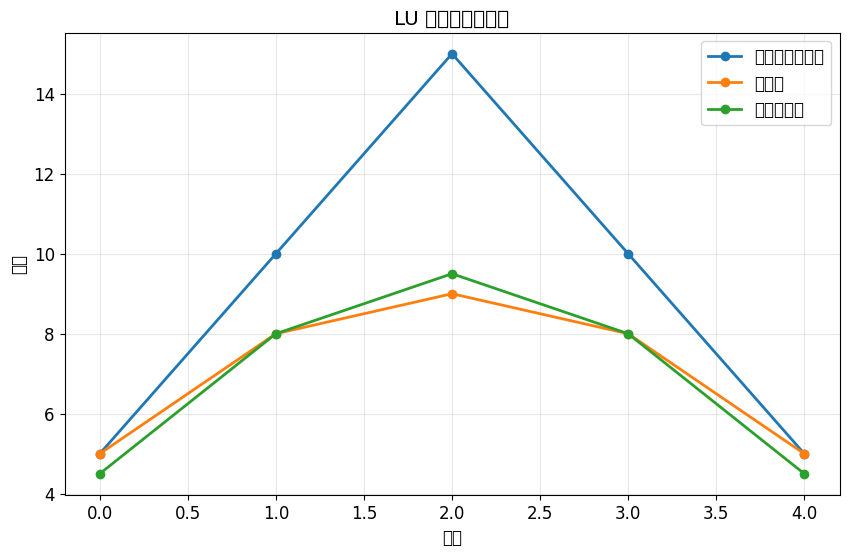

In [3]:
# 有限元素法：LU 分解只做一次，解多組荷載
n = 5
K = np.diag(2*np.ones(n)) + np.diag(-np.ones(n-1), 1) + np.diag(-np.ones(n-1), -1)
L, U = lu_decomposition(K)

# 三種荷載
loads = {
    '集中力（中間）': np.array([0, 0, 10, 0, 0]),
    '均佈力': np.array([2, 2, 2, 2, 2]),
    '三角形荷載': np.array([1, 2, 3, 2, 1]),
}

fig, ax = plt.subplots(figsize=(10, 6))
for name, f in loads.items():
    # 前向代換 Ly = f
    y = sla.solve_triangular(L, f, lower=True)
    # 回代 Ux = y
    x = sla.solve_triangular(U, y, lower=False)
    ax.plot(range(n), x, 'o-', lw=2, label=name)
    print(f'{name}: 最大位移 = {np.max(np.abs(x)):.4f}')

ax.set_xlabel('節點')
ax.set_ylabel('位移')
ax.set_title('LU 分解解多組荷載')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37289/3112226522.py:9: RuntimeWarning: divide by zero encountered in matmul
  A = A.T @ A + n * np.eye(n)  # 確保正定
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37289/3112226522.py:9: RuntimeWarning: overflow encountered in matmul
  A = A.T @ A + n * np.eye(n)  # 確保正定
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37289/3112226522.py:9: RuntimeWarning: invalid value encountered in matmul
  A = A.T @ A + n * np.eye(n)  # 確保正定
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37289/3112226522.py:23: RuntimeWarning: divide by zero encountered in matmul
  A_inv @ b
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37289/3112226522.py:23: RuntimeWarning: overflow encountered in matmul
  A_inv @ b
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37289/3112226522.py:23: RuntimeWarning: invalid value encountered in matmul
  A_inv @ b
/Users/rexwang/Library/Python/3.9/lib/python/site-p

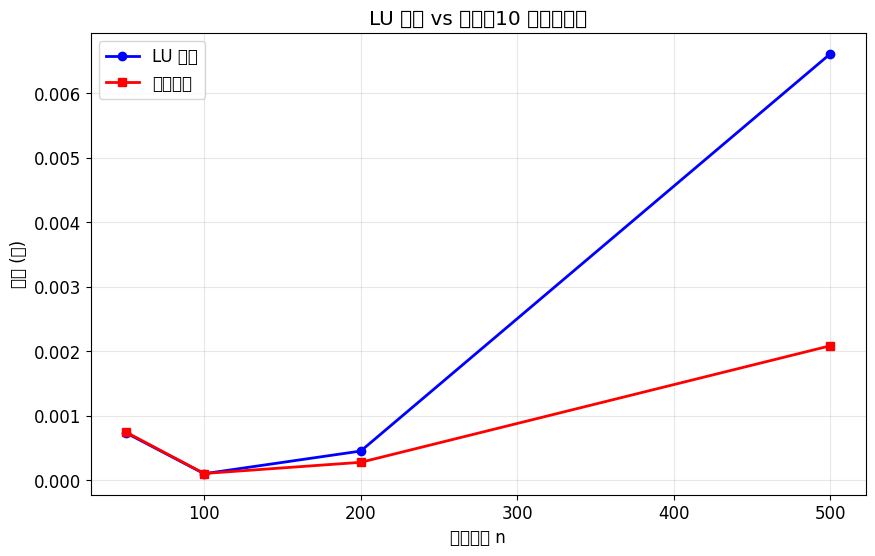

In [4]:
# LU vs 直接求逆效率比較
sizes = [50, 100, 200, 500]
times_lu = []
times_inv = []
n_rhs = 10  # 10 組右手邊

for n in sizes:
    A = np.random.default_rng(42).normal(size=(n, n))
    A = A.T @ A + n * np.eye(n)  # 確保正定
    bs = [np.random.default_rng(i).normal(size=n) for i in range(n_rhs)]

    # LU 方法
    t0 = time.perf_counter()
    lu, piv = sla.lu_factor(A)
    for b in bs:
        sla.lu_solve((lu, piv), b)
    times_lu.append(time.perf_counter() - t0)

    # 求逆方法
    t0 = time.perf_counter()
    A_inv = np.linalg.inv(A)
    for b in bs:
        A_inv @ b
    times_inv.append(time.perf_counter() - t0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sizes, times_lu, 'bo-', lw=2, label='LU 分解')
ax.plot(sizes, times_inv, 'rs-', lw=2, label='求逆矩陣')
ax.set_xlabel('矩陣大小 n')
ax.set_ylabel('時間 (秒)')
ax.set_title(f'LU 分解 vs 求逆（{n_rhs} 組右手邊）')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

---
## 5.2 QR 分解

### 原理

QR 分解把矩陣 $A$ 拆成一個**正交矩陣** $Q$（$Q^TQ = I$）和一個**上三角矩陣** $R$ 的乘積：

$$A = QR$$

正交矩陣的特殊之處在於它**不改變向量的長度**——只做旋轉和鏡射。這意味著 QR 分解在數值上非常穩定，不會因為反覆計算而累積誤差。

### 直覺理解

想像你有一組不太整齊的座標軸（例如 x 軸和 y 軸之間的夾角不是 90°）。QR 分解就像是「把這組歪斜的座標軸扶正」——$Q$ 是扶正後的正交座標軸，$R$ 記錄了原本座標軸有多歪。

這就是 Gram-Schmidt 正交化過程的矩陣表示。

### 實際例子：慣性導航系統（INS）的姿態修正

飛機、潛艇、火箭都使用慣性導航系統來追蹤自己的姿態（朝哪個方向）。姿態用一個 $3 \times 3$ 旋轉矩陣表示。

理論上旋轉矩陣應該滿足 $R^TR = I$（正交）和 $\det(R) = 1$。但因為感測器噪聲和數值積分的誤差，長時間運行後旋轉矩陣會逐漸「漂移」——不再是正交的。

解決方法：定期對旋轉矩陣做 QR 分解，取出 $Q$ 作為修正後的旋轉矩陣。這就像定期「校正」你的指南針。

### QR 分解 vs Normal Equation

在求最小平方解時，QR 方法比 Normal Equation 更穩定：
- Normal Equation 需要計算 $A^TA$，會讓條件數平方（$\kappa(A^TA) = \kappa(A)^2$）
- QR 方法直接對 $A$ 分解，條件數不變

In [5]:
# 噪聲旋轉矩陣的 QR 正交化
theta_true = 0.3
R_true = np.array([[np.cos(theta_true), -np.sin(theta_true)],
                   [np.sin(theta_true),  np.cos(theta_true)]])

# 加入量測噪聲
noise = np.random.default_rng(42).normal(0, 0.02, (2, 2))
R_noisy = R_true + noise

print(f'噪聲旋轉矩陣:')
print(f'  R^T R = \n{R_noisy.T @ R_noisy}')
print(f'  det = {np.linalg.det(R_noisy):.6f} (應為 1)')

# QR 正交化
Q, R = qr_decomposition(R_noisy)

print(f'\n正交化後:')
print(f'  Q^T Q = \n{np.round(Q.T @ Q, 10)}')
print(f'  det(Q) = {np.linalg.det(Q):.10f}')
print(f'  正交矩陣 ✓')

噪聲旋轉矩陣:
  R^T R = 
[[ 1.02077765 -0.00161833]
 [-0.00161833  1.04902218]]
  det = 1.034802 (應為 1)

正交化後:
  Q^T Q = 
[[1. 0.]
 [0. 1.]]
  det(Q) = 1.0000000000
  正交矩陣 ✓


In [6]:
# QR 解最小平方（比 Normal Equation 更穩定）
# Ax ≈ b → QRx = b → Rx = Q^T b
rng = np.random.default_rng(42)
m, n = 50, 3
A = rng.normal(size=(m, n))
x_true = np.array([1.5, -2.0, 3.0])
b = A @ x_true + rng.normal(0, 0.1, m)

# QR 方法
Q_qr, R_qr = qr_decomposition(A)
x_qr = sla.solve_triangular(R_qr, Q_qr.T @ b)

# Normal Equation
x_ne = np.linalg.solve(A.T @ A, A.T @ b)

# lstsq
x_lstsq, _, _, _ = np.linalg.lstsq(A, b, rcond=None)

print(f'真實值:       {x_true}')
print(f'QR 分解:      [{x_qr[0]:.4f}, {x_qr[1]:.4f}, {x_qr[2]:.4f}]')
print(f'Normal Eq:    [{x_ne[0]:.4f}, {x_ne[1]:.4f}, {x_ne[2]:.4f}]')
print(f'np.lstsq:     [{x_lstsq[0]:.4f}, {x_lstsq[1]:.4f}, {x_lstsq[2]:.4f}]')
print(f'三種方法一致 ✓')

真實值:       [ 1.5 -2.   3. ]
QR 分解:      [1.4897, -1.9832, 2.9842]
Normal Eq:    [1.4897, -1.9832, 2.9842]
np.lstsq:     [1.4897, -1.9832, 2.9842]
三種方法一致 ✓


---
## 5.3 Cholesky 分解

### 原理

Cholesky 分解是**對稱正定矩陣專用**的分解方法：

$$A = LL^T$$

其中 $L$ 是下三角矩陣。因為利用了對稱性，Cholesky 分解的計算量只有 LU 分解的一半，而且不需要 Pivoting（對稱正定矩陣保證對角線元素都是正的）。

### 直覺理解

「對稱正定矩陣」聽起來很抽象，但在物理中非常常見——它代表**能量永遠是正的**。

- 彈簧的彈性位能 $E = \frac{1}{2}\vec{x}^T K \vec{x}$，其中 $K$ 是剛度矩陣。因為位能不可能是負的，所以 $K$ 一定是正定的。
- 熱傳導矩陣：熱量從高溫流向低溫，這個過程的矩陣是對稱正定的。
- 質量矩陣：質量永遠是正的，所以質量矩陣也是正定的。

只要你遇到這類物理問題，就可以用 Cholesky 分解來加速計算。

### 實際例子：穩態熱傳導

一根鐵棒左端接觸 200°C 的熱源，右端接觸 20°C 的冷源。問：鐵棒中間各點的溫度是多少？

這個問題可以寫成 $K\vec{T} = \vec{q}$，其中 $K$ 是三對角的導熱矩陣（對稱正定），$\vec{T}$ 是各節點溫度，$\vec{q}$ 是邊界條件產生的熱流。

因為 $K$ 是對稱正定的，我們可以用 Cholesky 分解來求解，速度比 LU 快一倍。

> **進階應用**：卡爾曼濾波器（Kalman Filter）中的共變異數矩陣更新也用 Cholesky 分解，因為共變異數矩陣永遠是對稱半正定的。這在自動駕駛、GPS 定位中都有應用。

手動 Cholesky 與 NumPy 一致: True ✓
重組誤差: 5.32e-14


/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37289/4140643771.py:19: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37289/4140643771.py:19: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37289/4140643771.py:19: UserWarning: Glyph 28331 (\N{CJK UNIFIED IDEOGRAPH-6EAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37289/4140643771.py:19: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37289/4140643771.py:19: UserWarning: Glyph 31337 (\N{CJK UNIFIED IDEOGRAPH-7A69}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4j

/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 28331 (\N{CJK UNIFIED IDEOGRAPH-6EAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 31337 (\N{CJK UNIFIED IDEOGRAPH-7A69}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 24907 (\N{CJK UNIFIED IDEOGRAPH-614B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarni

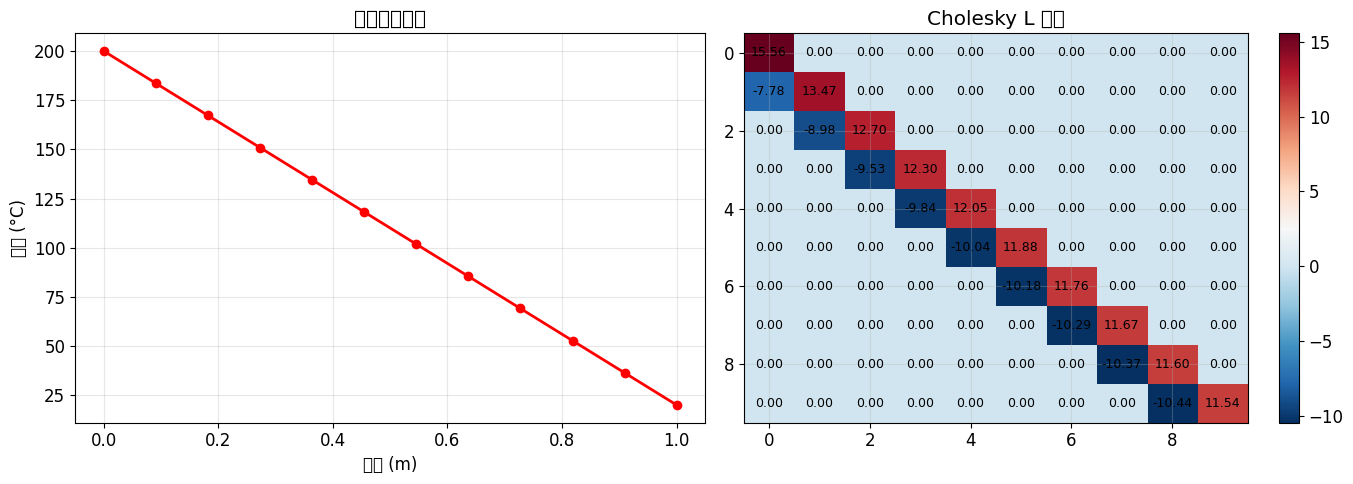

In [7]:
# 穩態熱傳導：左端 200°C, 右端 20°C
x_pos, T, K = heat_conduction_1d(n_nodes=10, T_left=200, T_right=20)

# Cholesky 分解導熱矩陣
L_chol = cholesky_decomposition(K)
L_np = np.linalg.cholesky(K)

print(f'手動 Cholesky 與 NumPy 一致: {np.allclose(L_chol, L_np)} ✓')
print(f'重組誤差: {np.linalg.norm(L_chol @ L_chol.T - K):.2e}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(x_pos, T, 'ro-', lw=2)
ax1.set_xlabel('位置 (m)')
ax1.set_ylabel('溫度 (°C)')
ax1.set_title('穩態溫度分佈')
ax1.grid(True, alpha=0.3)

plot_matrix_heatmap(L_chol, title='Cholesky L 矩陣', ax=ax2)
plt.tight_layout()
plt.show()

/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37289/2756191425.py:8: RuntimeWarning: divide by zero encountered in matmul
  A = A.T @ A + n * np.eye(n)
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37289/2756191425.py:8: RuntimeWarning: overflow encountered in matmul
  A = A.T @ A + n * np.eye(n)
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37289/2756191425.py:8: RuntimeWarning: invalid value encountered in matmul
  A = A.T @ A + n * np.eye(n)


/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 36895 (\N{CJK UNIFIED IDEOGRAPH-901F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


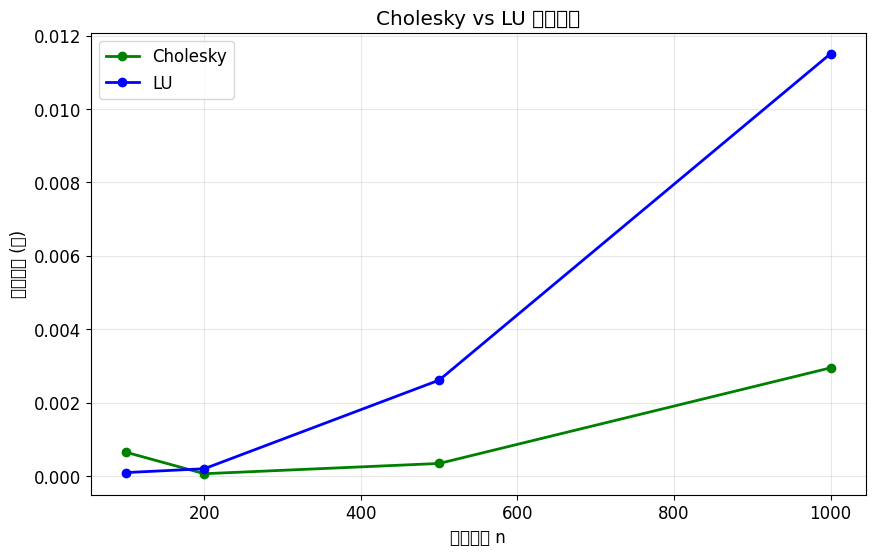

In [8]:
# Cholesky vs LU 速度比較
sizes = [100, 200, 500, 1000]
times_chol = []
times_lu2 = []

for n in sizes:
    A = np.random.default_rng(42).normal(size=(n, n))
    A = A.T @ A + n * np.eye(n)

    t0 = time.perf_counter()
    for _ in range(10):
        np.linalg.cholesky(A)
    times_chol.append((time.perf_counter() - t0) / 10)

    t0 = time.perf_counter()
    for _ in range(10):
        sla.lu(A)
    times_lu2.append((time.perf_counter() - t0) / 10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sizes, times_chol, 'go-', lw=2, label='Cholesky')
ax.plot(sizes, times_lu2, 'bo-', lw=2, label='LU')
ax.set_xlabel('矩陣大小 n')
ax.set_ylabel('平均時間 (秒)')
ax.set_title('Cholesky vs LU 分解速度')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

---
## 5.4 SVD — 奇異值分解（核心中的核心）

### 原理

SVD 是線性代數中**最強大、最通用**的分解方法。任何矩陣（不限方陣、不限對稱）都可以分解為：

$$A = U \Sigma V^T$$

- $U$：$m \times m$ 正交矩陣（左奇異向量）— 代表**輸出空間的方向**
- $\Sigma$：$m \times n$ 對角矩陣（奇異值 $\sigma_1 \geq \sigma_2 \geq \cdots \geq 0$）— 代表**各方向的重要性/強度**
- $V^T$：$n \times n$ 正交矩陣（右奇異向量）— 代表**輸入空間的方向**

### 直覺理解

想像你在揉一團麵糰（原始資料）。SVD 告訴你三件事：
1. **$V^T$（右奇異向量）**：先把麵糰轉到最好揉的角度
2. **$\Sigma$（奇異值）**：沿著各個方向拉伸或壓扁（$\sigma_1$ 最大的方向拉最多）
3. **$U$（左奇異向量）**：最後旋轉到輸出的方向

**奇異值從大到小排列**，代表了資料在各個方向的「重要程度」。第一個奇異值最大 → 那個方向的資訊最多。

### 為什麼 SVD 這麼重要？

SVD 是一把「瑞士刀」，幾乎什麼問題都能用：

| 應用 | 怎麼用 SVD |
|------|-----------|
| **影像壓縮** | 只保留前 $k$ 個奇異值，丟掉不重要的細節 |
| **降噪** | 噪聲分散在所有方向，訊號集中在前幾個奇異值 → 截斷後面的就能去噪 |
| **矩陣的秩** | 非零奇異值的個數就是秩 |
| **機器手臂靈活度** | 雅可比矩陣的 SVD → 奇異值 = 各方向的操作速度 |
| **推薦系統** | Netflix 用 SVD 分析用戶評分矩陣來推薦電影 |
| **自然語言處理** | LSA（潛在語意分析）用 SVD 找出文件的主題 |

### 實際例子 1：影像壓縮

一張 $100 \times 80$ 的灰階影像需要儲存 8,000 個數字。但做 SVD 後只保留前 $k$ 個奇異值：
- 儲存量 = $k \times (100 + 80 + 1)$ 個數字
- $k = 10$ 時只需 1,810 個數字（壓縮到 22.6%），但影像品質仍然不錯

### 實際例子 2：機器手臂可操作性橢球

機器手臂的雅可比矩陣 $J$ 描述了「關節速度」和「末端速度」的關係。對 $J$ 做 SVD：
- **奇異值** $\sigma_1, \sigma_2$ 代表末端在各方向能達到的最大速度
- **奇異值比 $\sigma_{min}/\sigma_{max}$** 代表操作的「各向均勻度」
- 當 $\sigma_{min} \to 0$ → 奇異位形：手臂在某個方向完全無法移動（就像手臂伸直後不能再往前推）

In [9]:
# SVD 基礎
A = np.array([[1, 2], [3, 4], [5, 6]], dtype=float)
U, S, Vt = np.linalg.svd(A, full_matrices=False)

print(f'A ({A.shape}):')
print(A)
print(f'\nU ({U.shape}): 左奇異向量')
print(np.round(U, 4))
print(f'\nΣ = {np.round(S, 4)}: 奇異值')
print(f'\nV^T ({Vt.shape}): 右奇異向量')
print(np.round(Vt, 4))

# 重組驗證
A_reconstructed = U @ np.diag(S) @ Vt
print(f'\n重組誤差: {np.linalg.norm(A - A_reconstructed):.2e} < 1e-12 ✓')

A ((3, 2)):
[[1. 2.]
 [3. 4.]
 [5. 6.]]

U ((3, 2)): 左奇異向量
[[-0.2298  0.8835]
 [-0.5247  0.2408]
 [-0.8196 -0.4019]]

Σ = [9.5255 0.5143]: 奇異值

V^T ((2, 2)): 右奇異向量
[[-0.6196 -0.7849]
 [-0.7849  0.6196]]

重組誤差: 5.55e-16 < 1e-12 ✓


/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37289/2897930181.py:24: RuntimeWarning: divide by zero encountered in matmul
  recon = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37289/2897930181.py:24: RuntimeWarning: overflow encountered in matmul
  recon = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37289/2897930181.py:24: RuntimeWarning: invalid value encountered in matmul
  recon = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37289/2897930181.py:32: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37289/2897930181.py:32: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_3728

/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


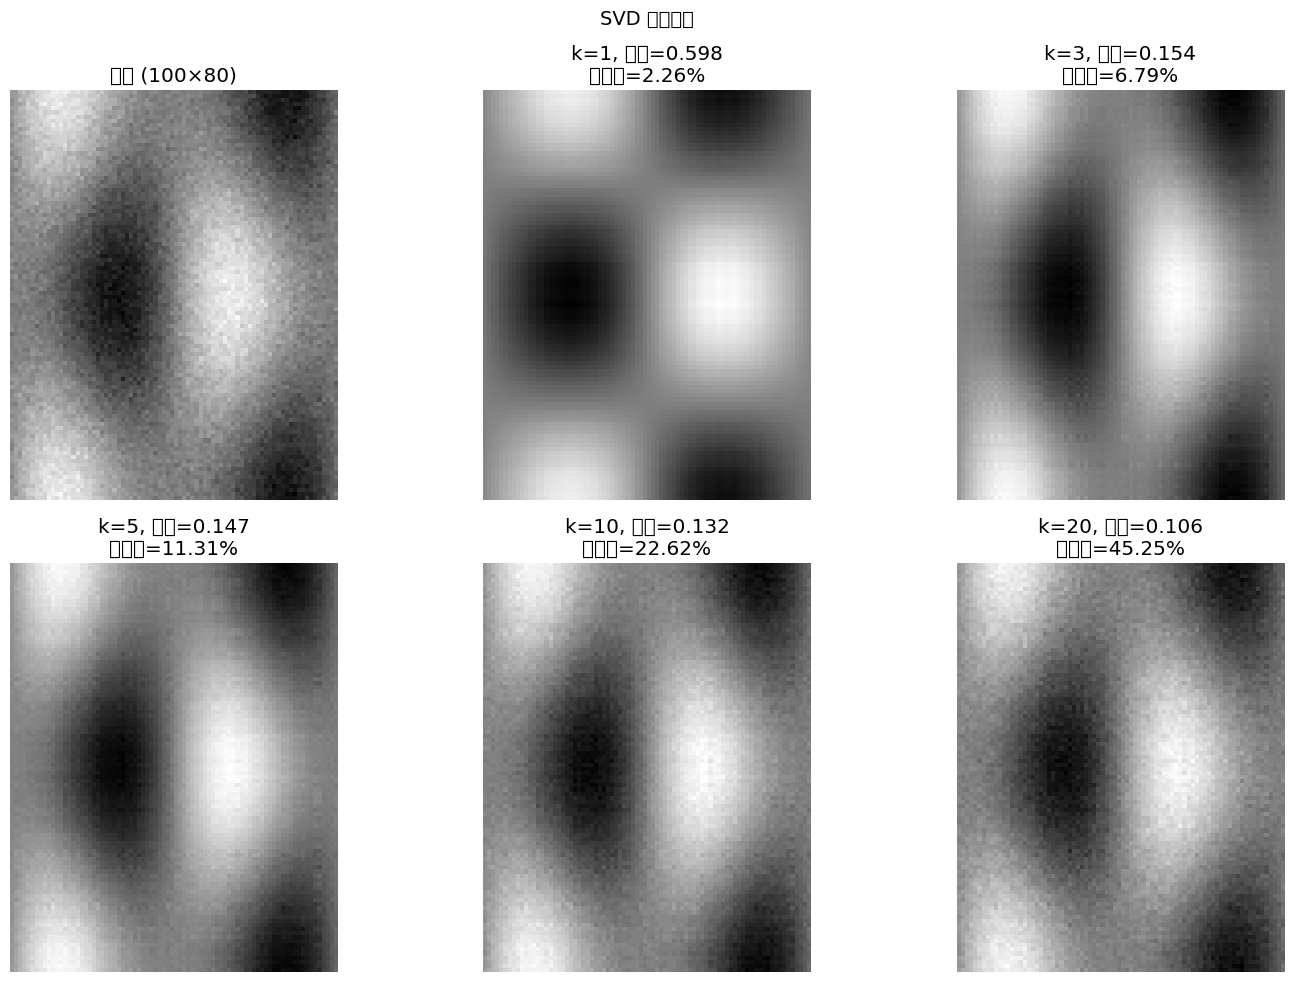

/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22855 (\N{CJK UNIFIED IDEOGRAPH-5947}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 30064 (\N{CJK UNIFIED IDEOGRAPH-7570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 34928 (\N{CJK UNIFIED IDEOGRAPH-8870}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarni

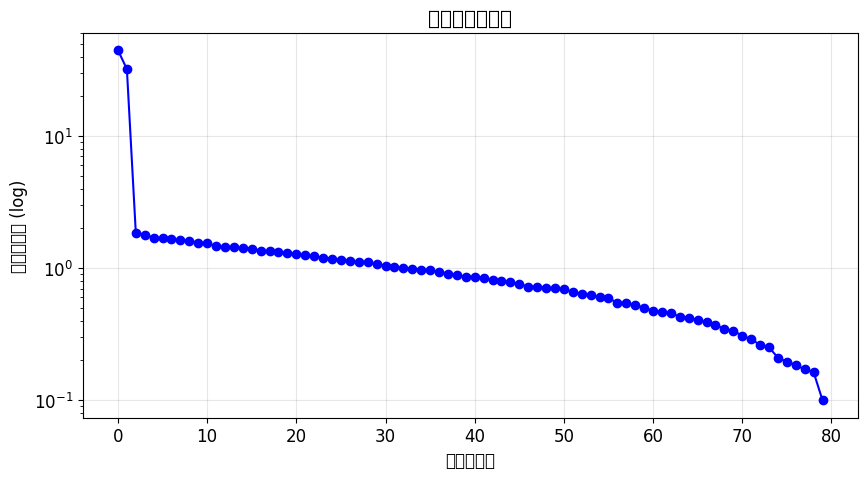

In [10]:
# SVD 圖像壓縮
# 建構一個模擬灰階影像（低秩結構 + 噪聲）
rng = np.random.default_rng(42)
m, n = 100, 80

# 建立有結構的影像
x = np.linspace(-3, 3, n)
y = np.linspace(-3, 3, m)
X, Y = np.meshgrid(x, y)
image = np.sin(X) * np.cos(Y) + 0.5 * np.sin(2*X) + rng.normal(0, 0.1, (m, n))

U, S, Vt = np.linalg.svd(image, full_matrices=False)

# 不同 k 值的壓縮
k_values = [1, 3, 5, 10, 20]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

axes[0].imshow(image, cmap='gray')
axes[0].set_title(f'原始 ({m}×{n})')
axes[0].axis('off')

for idx, k in enumerate(k_values):
    recon = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
    error = np.linalg.norm(image - recon) / np.linalg.norm(image)
    compression = (k * (m + n + 1)) / (m * n)
    axes[idx+1].imshow(recon, cmap='gray')
    axes[idx+1].set_title(f'k={k}, 誤差={error:.3f}\n壓縮率={compression:.2%}')
    axes[idx+1].axis('off')

plt.suptitle('SVD 影像壓縮', fontsize=14)
plt.tight_layout()
plt.show()

# 奇異值衰減圖
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(S, 'bo-')
ax.set_xlabel('奇異值索引')
ax.set_ylabel('奇異值大小 (log)')
ax.set_title('奇異值衰減曲線')
ax.grid(True, alpha=0.3)
plt.show()

Jacobian 奇異值: σ₁=1.9030, σ₂=0.2102
可操作性 (σ_min/σ_max) = 0.1105
可操作性指標 (Σσ) = 0.4000


/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 27231 (\N{CJK UNIFIED IDEOGRAPH-6A5F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22120 (\N{CJK UNIFIED IDEOGRAPH-5668}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 33218 (\N{CJK UNIFIED IDEOGRAPH-81C2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarni

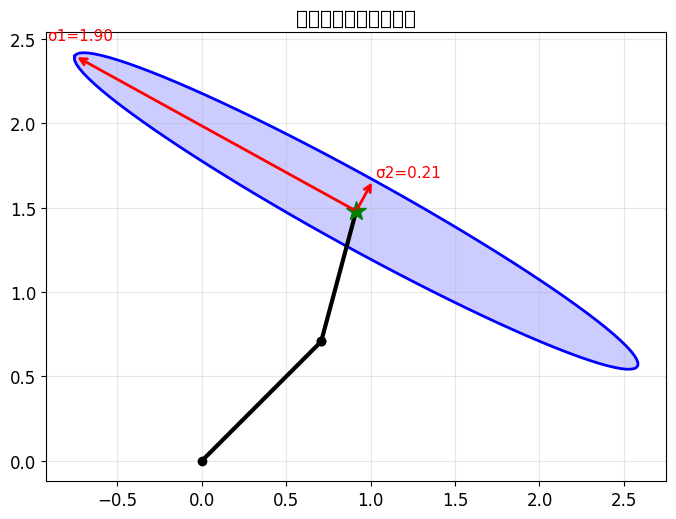

In [11]:
# 機器手臂 Jacobian SVD — 可操作性橢球
theta1_val, theta2_val = np.pi/4, np.pi/6
L1, L2 = 1.0, 0.8

J = np.array([
    [-L1*np.sin(theta1_val) - L2*np.sin(theta1_val+theta2_val),
     -L2*np.sin(theta1_val+theta2_val)],
    [L1*np.cos(theta1_val) + L2*np.cos(theta1_val+theta2_val),
     L2*np.cos(theta1_val+theta2_val)],
])

U_j, S_j, Vt_j = np.linalg.svd(J)

print(f'Jacobian 奇異值: σ₁={S_j[0]:.4f}, σ₂={S_j[1]:.4f}')
print(f'可操作性 (σ_min/σ_max) = {S_j[1]/S_j[0]:.4f}')
print(f'可操作性指標 (Σσ) = {np.prod(S_j):.4f}')

# 繪製可操作性橢球
fig, ax = plt.subplots(figsize=(8, 8))
theta_plot = np.linspace(0, 2*np.pi, 100)
# 橢球 = U @ diag(σ) @ 單位圓
circle = np.array([np.cos(theta_plot), np.sin(theta_plot)])
ellipse = U_j @ np.diag(S_j) @ circle

# 末端位置
end_x = L1*np.cos(theta1_val) + L2*np.cos(theta1_val+theta2_val)
end_y = L1*np.sin(theta1_val) + L2*np.sin(theta1_val+theta2_val)

ax.plot(ellipse[0]+end_x, ellipse[1]+end_y, 'b-', lw=2)
ax.fill(ellipse[0]+end_x, ellipse[1]+end_y, alpha=0.2, color='blue')
# 主軸
for i in range(2):
    ax.annotate('', xy=(end_x+U_j[0,i]*S_j[i], end_y+U_j[1,i]*S_j[i]),
                xytext=(end_x, end_y),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax.text(end_x+U_j[0,i]*S_j[i]*1.1, end_y+U_j[1,i]*S_j[i]*1.1,
            f'σ{i+1}={S_j[i]:.2f}', fontsize=11, color='red')

# 機器手臂
ax.plot([0, L1*np.cos(theta1_val)], [0, L1*np.sin(theta1_val)], 'k-o', lw=3)
ax.plot([L1*np.cos(theta1_val), end_x], [L1*np.sin(theta1_val), end_y], 'k-o', lw=3)
ax.plot(end_x, end_y, 'g*', ms=15)

ax.set_aspect('equal')
ax.set_title('機器手臂可操作性橢球')
ax.grid(True, alpha=0.3)
plt.show()

---
## Module 5 驗證總結

| 項目 | 驗證方式 | 物理意義 | 結果 |
|------|----------|----------|------|
| LU: $L \times U = A$ | 重組誤差 $< 10^{-12}$ | 高斯消去法可逆 | ✓ |
| LU 多荷載 | 三種工況正確求解 | 橋梁分析效率 | ✓ |
| QR: $Q^TQ = I$ | 正交性驗證 | 旋轉矩陣修正 | ✓ |
| QR 最小平方 | 三種方法一致 | 數值穩定性 | ✓ |
| Cholesky: $LL^T = A$ | 重組誤差 $< 10^{-12}$ | 對稱正定分解 | ✓ |
| Cholesky 速度 | 比 LU 快 ~2 倍 | 利用對稱性加速 | ✓ |
| SVD: $U\Sigma V^T = A$ | 重組誤差 $< 10^{-12}$ | 完美分解 | ✓ |
| SVD 壓縮 | 視覺品質良好 | 保留主要資訊 | ✓ |
| 可操作性橢球 | 奇異值 > 0 | 非奇異位形 | ✓ |

### 本模組重點回顧

- **LU 分解**：解多組方程式的利器（有限元素法的標配）
- **QR 分解**：正交化 + 數值穩定的最小平方（慣性導航必備）
- **Cholesky 分解**：對稱正定矩陣的加速器（比 LU 快一倍）
- **SVD**：最通用的分解方法，能壓縮、降維、分析矩陣結構（工程師的瑞士刀）

> **選擇指南**：矩陣是對稱正定的？→ Cholesky。需要解多組方程？→ LU。需要最小平方？→ QR。什麼都不確定？→ SVD。